In [1]:
!nvidia-smi

Wed May 13 11:58:51 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 590.48.01              Driver Version: 590.48.01      CUDA Version: 13.1     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA H100 PCIe               On  |   00000000:01:00.0 Off |                    0 |
| N/A   33C    P0             79W /  350W |   48271MiB /  81559MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [2]:
# Выбрать GPU с минимальной занятой памятью
import subprocess
import os

def get_free_gpu():
    result = subprocess.check_output(
        ["nvidia-smi", "--query-gpu=memory.used", "--format=csv,nounits,noheader"]
    )
    memory = [int(x) for x in result.decode().strip().split("\n")]
    return memory.index(min(memory)), min(memory)

gpu_id, memory_used = get_free_gpu()
os.environ["CUDA_VISIBLE_DEVICES"] = str(gpu_id)

print(f"Using GPU {gpu_id} (memory usage: {memory_used}MiB)")

Using GPU 4 (memory usage: 4MiB)


In [3]:
# import os
# os.environ["CUDA_VISIBLE_DEVICES"] = "5"

In [3]:
path = "/var/essdata/DN_1/storage/home/ttn/data/swe_trajectories/nemotron"

https://unsloth.ai/docs/basics/chat-templates#applying-chat-templates-with-unsloth

In [11]:
from unsloth.chat_templates import CHAT_TEMPLATES
print(list(CHAT_TEMPLATES.keys()))

['unsloth', 'zephyr', 'chatml', 'mistral', 'llama', 'vicuna', 'vicuna_old', 'vicuna old', 'alpaca', 'gemma', 'gemma_chatml', 'gemma2', 'gemma2_chatml', 'llama-3', 'llama3', 'phi-3', 'phi-35', 'phi-3.5', 'llama-3.1', 'llama-31', 'llama-3.2', 'llama-3.3', 'llama-32', 'llama-33', 'qwen-2.5', 'qwen-25', 'qwen25', 'qwen2.5', 'phi-4', 'gemma-3', 'gemma3', 'qwen-3', 'qwen3', 'gemma-3n', 'gemma3n', 'gpt-oss', 'gptoss', 'qwen3-instruct', 'qwen3-thinking', 'lfm-2', 'starling', 'yi-chat']


In [14]:
print(CHAT_TEMPLATES['qwen3'][0]) # это вот те преобразования, которые сделает tokenizer.apply_chat_template() (см. ниже)


{%- if tools %}
    {{- '<|im_start|>system
' }}
    {%- if messages[0].role == 'system' %}
        {{- messages[0].content + '

' }}
    {%- endif %}
    {{- "# Tools

You may call one or more functions to assist with the user query.

You are provided with function signatures within <tools></tools> XML tags:
<tools>" }}
    {%- for tool in tools %}
        {{- "
" }}
        {{- tool | tojson }}
    {%- endfor %}
    {{- "
</tools>

For each function call, return a json object with function name and arguments within <tool_call></tool_call> XML tags:
<tool_call>
{\"name\": <function-name>, \"arguments\": <args-json-object>}
</tool_call><|im_end|>
" }}
{%- else %}
    {%- if messages[0].role == 'system' %}
        {{- '<|im_start|>system
' + messages[0].content + '<|im_end|>
' }}
    {%- endif %}
{%- endif %}
{%- set ns = namespace(multi_step_tool=true, last_query_index=messages|length - 1) %}
{%- for forward_message in messages %}
    {%- set index = (messages|length - 1) - loop.index

In [20]:
CHAT_TEMPLATES['qwen-3']==CHAT_TEMPLATES['qwen3']

True

In [4]:
from datasets import load_from_disk
import json
import re
from copy import deepcopy

#ds = load_from_disk(path)["r2e_gym"]

train_raw = load_from_disk("/var/essdata/DN_1/storage/home/ttn/data/swe_trajectories/nemotron_train_raw")
test_raw = load_from_disk("/var/essdata/DN_1/storage/home/ttn/data/swe_trajectories/nemotron_test_raw")

print(len(train_raw), len(test_raw))
print(len(set(train_raw["uuid"])), len(set(test_raw["uuid"])))

1000 100
1000 100


В предыдущей версии фильтрации (см. другой ноутбук) шаг считается полезным только по **самому `tool`-выводу** в этот момент: есть ли там признаки успеха, ошибки, `exit code 0` и так далее.<br>
То есть код **не смотрит вперёд**, чтобы понять, привёл ли неудачный шаг к прогрессу в следующих шагах.<br>
То есть нужен не только анализ одного `tool`, а маленькое "окно" вперёд по траектории.

Ниже версия с **окном вперёд на 1–2 шага**.

* каждый `assistant -> tool` шаг сначала классифицируется как `success / unknown / failure`;
* если это `failure`, то смотрим на **следующие 1–2 action-шага**;
* если там появляется **успех**, **новая ошибка** (т.е. не та же самая ошибка) или вообще **улучшение score**, то исходный неудачный шаг считаем полезным и оставляем.

In [6]:
avg_messages_before = sum(len(x["messages"]) for x in train_raw) / len(train_raw)
print("Среднее число сообщений до фильтрации:", avg_messages_before)

Среднее число сообщений до фильтрации: 124.338


In [5]:
# Какие tool-вызовы считаем "рабочими" шагами, которые надо анализировать
ACTION_NAMES = {"execute_bash", "str_replace_editor"}

# Порог фильтра:
# 1 = оставлять только явно полезные шаги (более жёсткий фильтр)
# 0 = сделать фильтр мягче
MIN_PROGRESS_SCORE = 1

# Признаки явной ошибки в tool-выводе
ERROR_PATTERNS = [
    "traceback",
    "error:",
    "exception",
    "failed",
    "failure",
    "not found",
    "no such file or directory",
    "permission denied",
    "command not found",
    "segmentation fault",
    "assertionerror",
]

# Признаки явного успеха в tool-выводе
SUCCESS_PATTERNS = [
    "all tests passed",
    "passed",
    "success",
    "successfully",
    "applied",
    "updated",
    "replaced",
    "saved",
    "done",
    "fixed",
]

def classify_tool_output(tool_name, content):
    """
    Классифицирует output tool как:
      - success  : явный успех
      - failure  : явная ошибка
      - unknown  : неясно, но может быть полезно

    Одновременно возвращает score и сигнатуру ошибки,
    чтобы можно было сравнивать текущую ошибку с будущими.
    """
    text = (content or "").lower()

    has_error = any(p in text for p in ERROR_PATTERNS)
    has_success = any(p in text for p in SUCCESS_PATTERNS)

    # Базовый score: положительный = более похоже на прогресс, отрицательный = на провал
    score = 0

    if has_error:
        score -= 3
    if has_success:
        score += 3

    # Дополнительная логика для bash-команд
    if tool_name == "execute_bash":
        # exit code 0 обычно означает успешный запуск команды
        if "exit code 0" in text:
            score += 2

        # -1, а не -2, потому что иногда exit code 1 всё же сопровождается полезным шагом вперёд: 
        # например, команда помогла получить точный текст ошибки, и потом assistant уже исправил проблему
        # но можно рассмотреть вариант и с -2
        if "exit code 1" in text:
            score -= 1

        # Типичный формат результатов тестов
        if re.search(r"\b\d+\s+passed\b", text):
            score += 3

        # Пустой вывод иногда тоже нормален
        if not text.strip():
            score += 1

    # Дополнительная логика для редактора файлов
    elif tool_name == "str_replace_editor":
        # Сообщения о применении или сохранении изменений — хороший признак
        if any(p in text for p in ["applied", "updated", "saved", "replaced", "patched"]):
            score += 2
        if "no changes made" in text:
            score -= 2

    # Определяем label
    if has_success and not has_error:
        label = "success"
    elif has_error and not has_success:
        label = "failure"
    else:
        label = "unknown"

    # Сигнатура ошибки — это короткий "ярлык" (сжатая метка) типа ошибки
    # Сигнатура ошибки нужна, чтобы понять:
    # ошибка та же самая или уже другая
    error_signature = None
    if label == "failure":
        for p in ERROR_PATTERNS:
            if p in text:
                error_signature = p
                break

        # Если ничего не совпало из шаблонов, пробуем вытащить общий вид исключения
        if error_signature is None:
            m = re.search(r"\b([A-Za-z_]*Error|Exception|Failure)\b", content or "")
            if m:
                error_signature = m.group(1).lower()
            else:
                error_signature = "generic_error"

    return label, score, error_signature


def get_future_action_steps(messages, start_idx, max_steps=2):
    """
    Смотрим вперёд от позиции start_idx и собираем следующие 1-2 action-шагa (по умолчанию: 2):
    assistant(tool_call action) -> tool

    Нужны именно action-шаги, а не think/finish.
    """
    future = []
    i = start_idx

    while i < len(messages) and len(future) < max_steps:
        msg = messages[i]
        role = msg["role"]

        # Пропускаем system/user
        if role in ("system", "user"):
            i += 1
            continue

        # Ищем только assistant-сообщения с tool_calls
        if role == "assistant":
            calls = msg.get("tool_calls") or []
            if not calls:
                i += 1
                continue

            call = calls[0]
            name = call.get("function", {}).get("name")

            # think не считаем action-шагом
            if name == "think":
                if i + 1 < len(messages) and messages[i + 1]["role"] == "tool":
                    # После think идёт tool (сообщение: Your thought has been logged)
                    i += 2
                else:
                    i += 1
                continue

            # finish тоже не нужен для lookahead
            if name == "finish":
                break

            # Нам нужны только обычные action-шаги
            if name in ACTION_NAMES and i + 1 < len(messages) and messages[i + 1]["role"] == "tool":
                tool_msg = messages[i + 1]
                label, score, sig = classify_tool_output(name, tool_msg.get("content") or "")
                future.append((label, score, sig))
                i += 2
                continue

        # Всё остальное просто пропускаем (до сюда уже по сути ничего не должно дойти)
        i += 1

    return future


def future_indicates_progress(current_score, current_sig, future_steps):
    """
    Проверяет, есть ли в следующих 1-2 шагах признаки того,
    что текущая ошибка была полезной, потому что после неё появился прогресс.

    Условие считается выполненным, если:
      - в будущем появился success
      - или future score стал лучше текущего
      - или появилась новая, отличающаяся ошибка
    """
    if not future_steps:
        return False

    future_scores = [score for _, score, _ in future_steps]
    best_future_score = max(future_scores)

    # Если следующий шаг явно лучше по score, это уже сигнал прогресса
    if best_future_score > current_score:
        return True

    for label, score, sig in future_steps:
        # Явный успех в ближайших шагах
        if label == "success":
            return True

        # Неясный, но всё же положительный шаг
        if label == "unknown" and score >= MIN_PROGRESS_SCORE:
            return True

        # Если ошибка изменилась, это часто значит, что траектория сдвинулась
        # и текущая неудача была полезной диагностикой
        if label == "failure":
            if current_sig is not None and sig is not None and sig != current_sig:
                return True

    return False


def convert_example(example):
    """
    Оставляет только progress-making шаги.

    Логика:
      1) system/user сохраняем всегда;
      2) think исключаем;
      3) обычный action шаг сохраняем, если:
         - он success;
         - или он unknown, но выглядит достаточно полезным;
         - или он failure, но в следующих 1-2 action-шагaх есть прогресс.
      4) finish сохраняем всегда.
    """
    messages = example["messages"]
    kept = []

    i = 0
    while i < len(messages):
        msg = messages[i]
        role = msg["role"]

        # system и user сохраняем без изменений
        if role in ("system", "user"):
            kept.append({
                "role": role,
                "content": msg.get("content") or "",
            })
            i += 1
            continue

        # Пропускаем всё, что не assistant (т.е. сообщения от tool)
        if role != "assistant":
            i += 1
            continue

        calls = msg.get("tool_calls") or []

        # Если tool_calls нет, сохраняем обычный assistant-ответ
        if not calls:
            kept.append({
                "role": "assistant",
                "content": msg.get("content") or "",
            })
            i += 1
            continue

        # В этих данных один tool-вызов на assistant-сообщение
        call = calls[0]
        name = call.get("function", {}).get("name")

        # Шаги think исключаем
        if name == "think":
            if i + 1 < len(messages) and messages[i + 1]["role"] == "tool":
                # После think идёт tool (сообщение: Your thought has been logged), поэтому пропускаем пару
                i += 2
            else:
                i += 1
            continue

        # Финальный ответ сохраняем всегда
        if name == "finish":
            kept.append({
                "role": "assistant",
                "content": msg.get("content") or "",
                "tool_calls": deepcopy(calls),
            })
            i += 1
            continue

        # Обычный action + следующий tool
        if name in ACTION_NAMES and i + 1 < len(messages) and messages[i + 1]["role"] == "tool":
            tool_msg = messages[i + 1]

            # Классифицируем текущий tool output
            current_label, current_score, current_sig = classify_tool_output(
                name,
                tool_msg.get("content") or ""
            )

            # Смотрим вперёд на 1-2 следующих action-шагa
            future_steps = get_future_action_steps(messages, i + 2, max_steps=2)

            # Правило сохранения:
            # - success сохраняем всегда
            # - unknown сохраняем, если он хотя бы немного полезный
            # - failure сохраняем только если дальше есть признаки прогресса
            keep_this_step = False

            if current_label == "success":
                keep_this_step = True
            elif current_label == "unknown":
                keep_this_step = current_score >= MIN_PROGRESS_SCORE
            elif current_label == "failure":
                keep_this_step = future_indicates_progress(
                    current_score=current_score,
                    current_sig=current_sig,
                    future_steps=future_steps
                )

            if keep_this_step:
                kept.append({
                    "role": "assistant",
                    "content": msg.get("content") or "",
                    "tool_calls": deepcopy(calls),
                })
                kept.append({
                    "role": "tool",
                    "content": tool_msg.get("content") or "",
                    "id": tool_msg.get("id"),
                })

            # Перепрыгиваем через assistant + tool
            i += 2
            continue

        # Всё остальное просто пропускаем (до сюда уже по сути ничего не должно дойти)
        i += 1

    # Проверяем, что в траектории остался хотя бы один полезный action-шаг
    has_useful_turn = any(
        m["role"] == "assistant" and m.get("tool_calls")
        for m in kept
    )

    return {
        "messages": kept,
        "keep": has_useful_turn,
        "kept_turns": sum(
            1 for m in kept
            if m["role"] == "assistant" and m.get("tool_calls")
        ),
    }


# Применяем фильтр ко всему датасету
train_ds = train_raw.map(convert_example, num_proc=8)
test_ds = test_raw.map(convert_example, num_proc=8)

len_ds_before = len(train_ds) + len(test_ds)
# Исключаем примеры, где ничего полезного не осталось
train_ds = train_ds.filter(lambda x: x["keep"])
test_ds = test_ds.filter(lambda x: x["keep"])
len_ds_after = len(train_ds) + len(test_ds)
print(f'Число полностью удалённых траектрорий: {len_ds_after - len_ds_before}')

Число полностью удалённых траектрорий: 0


In [8]:
avg_messages_after = sum(len(x["messages"]) for x in train_ds) / len(train_ds)
print("Среднее число сообщений после фильтрации:", avg_messages_after)

Среднее число сообщений после фильтрации: 84.066


In [9]:
percent_messages_left = 100 * avg_messages_after / avg_messages_before
print("Процент оставшихся сообщений:", percent_messages_left)

Процент оставшихся сообщений: 67.61086715243933


In [10]:
train_ds[0]

{'uuid': '403462c9-dbfb-1061-af69-98a051a77e65',
 'messages': [{'role': 'system',
   'content': 'You are OpenHands agent, a helpful AI assistant that can interact with a computer to solve tasks.\n\n<ROLE>\nYour primary role is to assist users by executing commands, modifying code, and solving technical problems effectively. You should be thorough, methodical, and prioritize quality over speed.\n* If the user asks a question, like "why is X happening", don\'t try to fix the problem. Just give an answer to the question.\n</ROLE>\n\n<EFFICIENCY>\n* Each action you take is somewhat expensive. Wherever possible, combine multiple actions into a single action, e.g. combine multiple bash commands into one, using sed and grep to edit/view multiple files at once.\n* When exploring the codebase, use efficient tools like find, grep, and git commands with appropriate filters to minimize unnecessary operations.\n</EFFICIENCY>\n\n<FILE_SYSTEM_GUIDELINES>\n* When a user provides a file path, do NOT as

In [6]:
from transformers import AutoTokenizer
from unsloth.chat_templates import get_chat_template

tokenizer = AutoTokenizer.from_pretrained("/var/essdata/DN_1/storage/home/ttn/models/Qwen3-4B")

def format_chat(example):
    return {
        "text": tokenizer.apply_chat_template(
            example["messages"],
            tokenize=False,
            add_generation_prompt=False
        )
    }
# прим.: tokenizer.apply_chat_template не знает роль tool, поэтому он превращает tool в user с <tool_response>

train_ds_fmt = train_ds.map(format_chat, num_proc=8)
test_ds_fmt = test_ds.map(format_chat, num_proc=8)

[unsloth.import_fixes|WARNING]Unsloth: torch==2.10.0 requires torchvision>=0.25.0, but found torchvision==0.15.2. Please refer to https://pytorch.org/get-started/previous-versions/ for more information.
Detected a newer torch version. Continuing with a warning. Set UNSLOTH_SKIP_TORCHVISION_CHECK=1 to silence this.


🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!


In [12]:
train_ds_fmt[0]

{'uuid': '403462c9-dbfb-1061-af69-98a051a77e65',
 'messages': [{'role': 'system',
   'content': 'You are OpenHands agent, a helpful AI assistant that can interact with a computer to solve tasks.\n\n<ROLE>\nYour primary role is to assist users by executing commands, modifying code, and solving technical problems effectively. You should be thorough, methodical, and prioritize quality over speed.\n* If the user asks a question, like "why is X happening", don\'t try to fix the problem. Just give an answer to the question.\n</ROLE>\n\n<EFFICIENCY>\n* Each action you take is somewhat expensive. Wherever possible, combine multiple actions into a single action, e.g. combine multiple bash commands into one, using sed and grep to edit/view multiple files at once.\n* When exploring the codebase, use efficient tools like find, grep, and git commands with appropriate filters to minimize unnecessary operations.\n</EFFICIENCY>\n\n<FILE_SYSTEM_GUIDELINES>\n* When a user provides a file path, do NOT as

In [13]:
train_ds_fmt[0]['text']

'<|im_start|>system\nYou are OpenHands agent, a helpful AI assistant that can interact with a computer to solve tasks.\n\n<ROLE>\nYour primary role is to assist users by executing commands, modifying code, and solving technical problems effectively. You should be thorough, methodical, and prioritize quality over speed.\n* If the user asks a question, like "why is X happening", don\'t try to fix the problem. Just give an answer to the question.\n</ROLE>\n\n<EFFICIENCY>\n* Each action you take is somewhat expensive. Wherever possible, combine multiple actions into a single action, e.g. combine multiple bash commands into one, using sed and grep to edit/view multiple files at once.\n* When exploring the codebase, use efficient tools like find, grep, and git commands with appropriate filters to minimize unnecessary operations.\n</EFFICIENCY>\n\n<FILE_SYSTEM_GUIDELINES>\n* When a user provides a file path, do NOT assume it\'s relative to the current working directory. First explore the file

In [14]:
import numpy as np

def tokenize_batch(batch):
    tokens = tokenizer(
        batch["text"],
        add_special_tokens=False,
        return_attention_mask=False,
        return_token_type_ids=False,
    )
    return {"length": [len(x) for x in tokens["input_ids"]]}

ds_with_len = train_ds_fmt.map(tokenize_batch, batched=True, batch_size=512, num_proc=8)

lengths = ds_with_len["length"]

print("Mean:", np.round(np.mean(lengths), 0))
print("Median:", np.median(lengths))
print("Max:", np.max(lengths))
print("95 percentile:", np.percentile(lengths, 95))

Map (num_proc=8):   0%|          | 0/1000 [00:00<?, ? examples/s]

Mean: 32291.0
Median: 29454.0
Max: 131224
95 percentile: 57466.24999999999


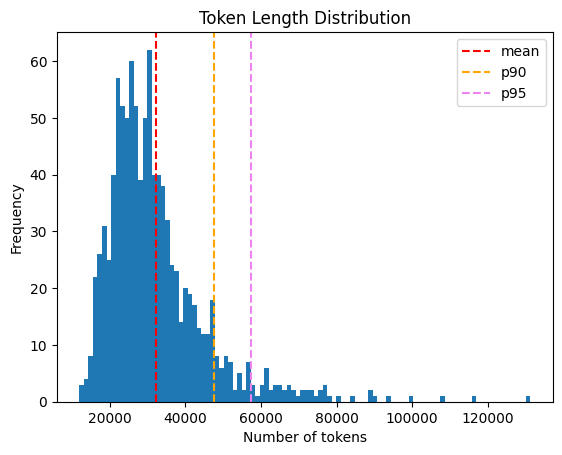

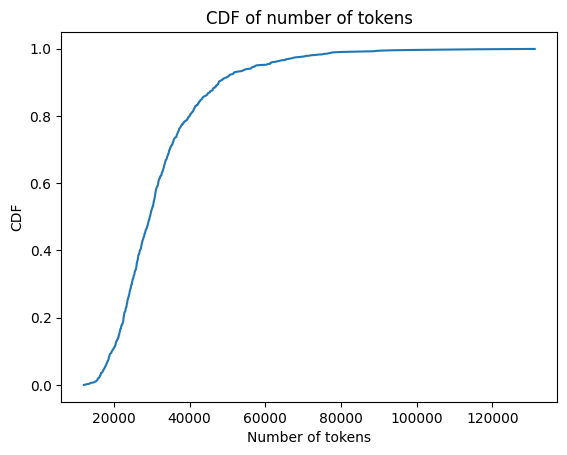

In [15]:
import matplotlib.pyplot as plt

plt.figure()
plt.hist(lengths, bins=100)

plt.axvline(np.mean(lengths), linestyle="--", label="mean", c='r')
plt.axvline(np.percentile(lengths, 90), linestyle="--", label="p90", c='orange')
plt.axvline(np.percentile(lengths, 95), linestyle="--", label="p95", c='violet')

plt.legend()
plt.xlabel("Number of tokens")
plt.ylabel("Frequency")
plt.title("Token Length Distribution")
plt.show()

sorted_lengths = sorted(lengths)
cdf = np.arange(len(sorted_lengths)) / len(sorted_lengths)

plt.figure()
plt.plot(sorted_lengths, cdf)
plt.xlabel("Number of tokens")
plt.ylabel("CDF")
plt.title("CDF of number of tokens")
plt.show()

In [7]:
MODEL_PATH = "/var/essdata/DN_1/storage/home/ttn/models/Qwen3-4B"
DATA_PATH = "/var/essdata/DN_1/storage/home/ttn/data/swe_trajectories/nemotron"
OUTPUT_PATH = "/var/essdata/DN_1/storage/home/ttn/models/qwen3-4b-swe-lora/ft_on_nemotron/filtered_trajectories_v2"

In [8]:
MAX_SEQ_LENGTH = 40960

In [18]:
from unsloth import FastLanguageModel
import torch

# Загрузка модели
print("Загрузка модели...")
model, tokenizer = FastLanguageModel.from_pretrained(
    model_name=MODEL_PATH,
    max_seq_length=MAX_SEQ_LENGTH,
    dtype=torch.bfloat16, # тип данных для вычислений
    load_in_4bit=True
)

# Настройка LoRA
model = FastLanguageModel.get_peft_model(
    model,
    r=16,  # ранг LoRA
    lora_alpha=32,  # alpha = 2*r для лучшей обучаемости
    lora_dropout=0.0,
    target_modules=[
        "q_proj", "k_proj", "v_proj", "o_proj",  # attention слои
        "gate_proj", "up_proj", "down_proj",  # MLP слои
    ],
    bias="none",
    use_gradient_checkpointing="unsloth",
    random_state=3407,
)

Загрузка модели...
==((====))==  Unsloth 2026.2.1: Fast Qwen3 patching. Transformers: 4.57.6.
   \\   /|    NVIDIA H100 PCIe. Num GPUs = 1. Max memory: 79.18 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 9.0. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

Unsloth 2026.2.1 patched 36 layers with 36 QKV layers, 36 O layers and 36 MLP layers.


In [19]:
from trl import SFTTrainer, SFTConfig

trainer = SFTTrainer(
    model=model, # Модель, которую мы обучаем. Обучаются только LoRA-параметры, а не вся модель
    train_dataset=train_ds_fmt, # наш подготовленный датасет для обучения
    eval_dataset=test_ds_fmt,
    tokenizer=tokenizer, # tokenizer; используется для преобразования текста в токены и паддинга последовательностей (если последовательность < max_seq_length)
    args=SFTConfig( # гиперпараметры обучения
        max_seq_length=MAX_SEQ_LENGTH, # максимальная длина входной последовательности токенов, которую модель может обработать за один раз
        per_device_train_batch_size=2, # Сколько примеров обрабатывается за один шаг в расчёте на один (!) GPU
        gradient_accumulation_steps=4, # Позволяет имитировать большой batch size. Идея: 1 шаг → считаем градиенты, но не обновляем веса
                                       # После 4 шага: градиенты суммируются → обновляем веса.
                                       # Формула эффективного batch effective_batch_size = per_device_train_batch_size * число GPU * gradient_accumulation
                                       # У нас: 2 * 1 (т.к. у нас 1 GPU) * 4 = 8. То есть модель фактически обучается на 8 примерах за шаг обновления.
        warmup_steps=10, # Первые шаги обучения делают плавный разогрев (↑) learning rate (предотвращает нестабильное обучение, уменьшает риск разрушить веса модели)
        num_train_epochs=1,
        #max_steps=60, # Убрать
        learning_rate=2e-4,  # TODO: experiment with different values (try 1e-4 to 5e-4)
        logging_steps=1, # Как часто выводить метрики. 1 = каждый шаг !ИЗМЕНЕНО!
        output_dir=OUTPUT_PATH, # Папка, куда сохраняются: checkpoints, финальная модель, логи
        optim="adamw_8bit", # adamw_8bit — версия AdamW с 8-битными состояниями. Использует библиотеку bitsandbytes. Плюсы: меньше VRAM и почти та же точность
        weight_decay=0.01, # Регуляризация. Добавляет штраф за большие веса: loss = original_loss + λ * ||weights||. Помогает избежать переобучения.
        lr_scheduler_type="linear", # Как меняется learning rate во времени. linear означает: warmup → затем плавное уменьшение
        seed=42,
        report_to="none", # Отключает логирование в сервисы вроде Weights & Biases и TensorBoard
    ),
)

effective_batch_size = (
    trainer.args.per_device_train_batch_size
    * trainer.args.gradient_accumulation_steps
)
steps_per_epoch = len(train_ds_fmt) // effective_batch_size # сколько шагов в одной эпохе

print(f"Effective batch size: {effective_batch_size}")
print(f"Steps per epoch: {steps_per_epoch}")
print(f"Total training steps: {trainer.args.max_steps}")
print(f"Approximate epochs: {trainer.args.max_steps / steps_per_epoch:.2f}") # max_steps < steps_per_epoch, то модель не проходит весь датасет даже один раз.
print(f"Learning rate: {trainer.args.learning_rate}")

Unsloth: Tokenizing ["text"] (num_proc=64):   0%|          | 0/1000 [00:00<?, ? examples/s]

Unsloth: Tokenizing ["text"] (num_proc=64):   0%|          | 0/100 [00:00<?, ? examples/s]

🦥 Unsloth: Padding-free auto-enabled, enabling faster training.
Effective batch size: 8
Steps per epoch: 125
Total training steps: -1
Approximate epochs: -0.01
Learning rate: 0.0002


https://unsloth.ai/docs/basics/troubleshooting-and-faqs#all-labels-in-your-dataset-are-100.-training-losses-will-be-all-0

In [20]:
from unsloth.chat_templates import train_on_responses_only

# всё до <|im_start|>assistant включительно → маскируется (loss = -100)
# всё внутри assistant сообщений → обучается
trainer = train_on_responses_only(
    trainer,
    instruction_part="<|im_start|>user",
    response_part="<|im_start|>assistant",
)

Map (num_proc=64):   0%|          | 0/1000 [00:00<?, ? examples/s]

Filter (num_proc=64):   0%|          | 0/1000 [00:00<?, ? examples/s]

Map (num_proc=64):   0%|          | 0/100 [00:00<?, ? examples/s]

Filter (num_proc=64):   0%|          | 0/100 [00:00<?, ? examples/s]

Если выдало предупреждение наподобие этого: `Unsloth: Removed 1483 out of 51029 samples from train_dataset where all labels were -100 (no response found after truncation). This prevents NaN loss during training.`, то это значит, что некоторые траектории были удалены из датасета из-за параметра max_seq_length, который настолько сильно обрезал их, что в них остались только начальные замаскированные токены (-100)

In [21]:
batch = next(iter(trainer.get_train_dataloader()))
print(batch["labels"][0])
print(len(batch["labels"][0]))

tensor([  -100,   -100,   -100,  ..., 151658, 151645,    198], device='cuda:0')
40143


Каждое число = id токена<br>
Точнее:
| Значение | Что означает                      |
| -------- | --------------------------------- |
| `>= 0`   | токен, по которому считается loss |
| `-100`   | **игнорируется (masked) при расчёте loss**         |


In [22]:
# выведем для первой траектории токены и их id

input_ids = batch["input_ids"][0]
labels = batch["labels"][0]
tokens = tokenizer.convert_ids_to_tokens(input_ids)

for t, l in zip(tokens, labels):
    print(f"{t:20} | {l}")

<|endoftext|>        | -100
<|endoftext|>        | -100
<|endoftext|>        | -100
<|endoftext|>        | -100
<|endoftext|>        | -100
<|endoftext|>        | -100
<|endoftext|>        | -100
<|endoftext|>        | -100
<|endoftext|>        | -100
<|endoftext|>        | -100
<|endoftext|>        | -100
<|endoftext|>        | -100
<|endoftext|>        | -100
<|endoftext|>        | -100
<|endoftext|>        | -100
<|endoftext|>        | -100
<|endoftext|>        | -100
<|endoftext|>        | -100
<|endoftext|>        | -100
<|endoftext|>        | -100
<|endoftext|>        | -100
<|endoftext|>        | -100
<|endoftext|>        | -100
<|endoftext|>        | -100
<|endoftext|>        | -100
<|endoftext|>        | -100
<|endoftext|>        | -100
<|endoftext|>        | -100
<|endoftext|>        | -100
<|endoftext|>        | -100
<|endoftext|>        | -100
<|endoftext|>        | -100
<|endoftext|>        | -100
<|endoftext|>        | -100
<|endoftext|>        | -100
<|endoftext|>       

In [23]:
# Обучение
print("Начало обучения...")
trainer.train()

# Сохранение модели
print("Сохранение модели...")
model.save_pretrained_merged(
    OUTPUT_PATH,
    tokenizer,
    save_method="merged_16bit", # ВСЕ веса сохраняются в 16-bit формате (не только LoRA адаптеры), 
                                # даже несмотря на то что ещё до дообучения загружали модель в 4-bit формате
                                # (load_in_4bit=True), потому что хранится информация для восстановления
                                # точнее: при расквантовании мы получаем приближённые значения весов 16-bit 
)

print(f"Обучение завершено! Модель сохранена в {OUTPUT_PATH}")

==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 1,000 | Num Epochs = 1 | Total steps = 125
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
 "-____-"     Trainable parameters = 33,030,144 of 4,055,498,240 (0.81% trained)


Начало обучения...
Unsloth: Will smartly offload gradients to save VRAM!


Step,Training Loss
1,0.885600
2,0.858300
3,0.807300
4,0.776200
5,0.746000
6,0.715100
7,0.598000
8,0.554000
9,0.568700
10,0.592400


Сохранение модели...
Detected local model directory: /var/essdata/DN_1/storage/home/ttn/models/Qwen3-4B
No existing and accessible Hugging Face cache directory found.


Unsloth: Preparing safetensor model files:  33%|██████████████                            | 1/3 [00:06<00:12,  6.16s/it]

...

Copied model-00003-of-00003.safetensors from local model directory


Unsloth: Preparing safetensor model files: 100%|██████████████████████████████████████████| 3/3 [00:14<00:00,  4.91s/it]


Copied model-00002-of-00003.safetensors from local model directory


Unsloth: Merging weights into 16bit: 100%|████████████████████████████████████████████████| 3/3 [00:46<00:00, 15.58s/it]


Unsloth: Merge process complete. Saved to `/var/essdata/DN_1/storage/home/ttn/models/qwen3-4b-swe-lora/ft_on_nemotron/filtered_trajectories_v2`
Обучение завершено! Модель сохранена в /var/essdata/DN_1/storage/home/ttn/models/qwen3-4b-swe-lora/ft_on_nemotron/filtered_trajectories_v2


In [24]:
!ls -lh /var/essdata/DN_1/storage/home/ttn/models/qwen3-4b-swe-lora/ft_on_nemotron/filtered_trajectories_v2

total 7.6G
-rw-r--r-- 1 root root 1.4K May 12 19:39 README.md
-rw-r--r-- 1 root root  707 May 12 19:40 added_tokens.json
-rw-r--r-- 1 root root 4.1K May 12 19:40 chat_template.jinja
drwxr-xr-x 2 root root 4.0K May 12 19:39 checkpoint-125
-rw-r--r-- 1 root root 1.8K May 12 19:40 config.json
-rw-r--r-- 1 root root 1.6M May 12 19:40 merges.txt
-rw-rw-r-- 1 root root 3.7G May 12 19:40 model-00001-of-00003.safetensors
-rw-rw-r-- 1 root root 3.8G May 12 19:41 model-00002-of-00003.safetensors
-rw-rw-r-- 1 root root  96M May 12 19:40 model-00003-of-00003.safetensors
-rw-rw-r-- 1 root root  33K Apr 29  2025 model.safetensors.index.json
-rw-r--r-- 1 root root  613 May 12 19:40 special_tokens_map.json
-rw-r--r-- 1 root root  11M May 12 19:40 tokenizer.json
-rw-r--r-- 1 root root 9.6K May 12 19:40 tokenizer_config.json
-rw-r--r-- 1 root root 2.7M May 12 19:40 vocab.json


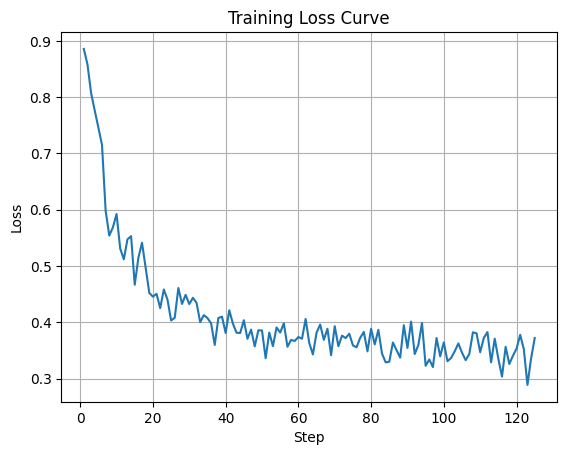

Initial loss: 0.8856
Final loss: 0.3721
Loss reduction: 58.0%

All assertions passed!


In [25]:
import matplotlib.pyplot as plt
log_history = trainer.state.log_history

# Extract the training loss values and corresponding steps from log_history
steps = [entry["step"] for entry in log_history if "loss" in entry]  # TODO
losses = [entry["loss"] for entry in log_history if "loss" in entry]  # TODO

# Plot the training loss curve
plt.figure()
plt.plot(steps, losses)
plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("Training Loss Curve")
plt.grid(True)
plt.show()

# Assertions
assert len(steps) > 0, "No training steps found in log history"
assert len(losses) > 0, "No loss values found in log history"
assert len(steps) == len(losses), "Steps and losses must have the same length"
assert losses[-1] < losses[0], "Training loss should decrease over time (last < first)"

print(f"Initial loss: {losses[0]:.4f}")
print(f"Final loss: {losses[-1]:.4f}")
print(f"Loss reduction: {(1 - losses[-1] / losses[0]) * 100:.1f}%")
print("\nAll assertions passed!")

In [26]:
print(steps, losses)

[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125] [0.8856, 0.8583, 0.8073, 0.7762, 0.746, 0.7151, 0.598, 0.554, 0.5687, 0.5924, 0.5311, 0.5119, 0.5474, 0.553, 0.4667, 0.5144, 0.5414, 0.497, 0.4523, 0.4455, 0.4506, 0.4252, 0.4583, 0.4406, 0.4033, 0.4081, 0.461, 0.4326, 0.4488, 0.4324, 0.4436, 0.4346, 0.4003, 0.4128, 0.4076, 0.3982, 0.3598, 0.4077, 0.4101, 0.381, 0.4214, 0.3977, 0.3815, 0.381, 0.4037, 0.3708, 0.387, 0.3573, 0.3858, 0.3855, 0.3363, 0.3818, 0.3576, 0.3909, 0.3817, 0.3983, 0.3566, 0.3687, 0.3669, 0.3739, 0.3708, 0.

In [27]:
log_history

[{'loss': 0.8856,
  'grad_norm': 1.1932451725006104,
  'learning_rate': 0.0,
  'epoch': 0.008,
  'step': 1},
 {'loss': 0.8583,
  'grad_norm': 1.1922751665115356,
  'learning_rate': 2e-05,
  'epoch': 0.016,
  'step': 2},
 {'loss': 0.8073,
  'grad_norm': 1.1254323720932007,
  'learning_rate': 4e-05,
  'epoch': 0.024,
  'step': 3},
 {'loss': 0.7762,
  'grad_norm': 0.9453939199447632,
  'learning_rate': 6e-05,
  'epoch': 0.032,
  'step': 4},
 {'loss': 0.746,
  'grad_norm': 0.804918110370636,
  'learning_rate': 8e-05,
  'epoch': 0.04,
  'step': 5},
 {'loss': 0.7151,
  'grad_norm': 0.5508959293365479,
  'learning_rate': 0.0001,
  'epoch': 0.048,
  'step': 6},
 {'loss': 0.598,
  'grad_norm': 0.5441292524337769,
  'learning_rate': 0.00012,
  'epoch': 0.056,
  'step': 7},
 {'loss': 0.554,
  'grad_norm': 0.26926714181900024,
  'learning_rate': 0.00014,
  'epoch': 0.064,
  'step': 8},
 {'loss': 0.5687,
  'grad_norm': 0.2059197574853897,
  'learning_rate': 0.00016,
  'epoch': 0.072,
  'step': 9},


In [9]:
# через Unsloth загружаем модель
from unsloth import FastLanguageModel
import torch

model_path = "/var/essdata/DN_1/storage/home/ttn/models/qwen3-4b-swe-lora/ft_on_nemotron/filtered_trajectories_v2"
MAX_SEQ_LENGTH = 40960

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name=model_path,
    max_seq_length=MAX_SEQ_LENGTH,
    dtype=torch.bfloat16,
    load_in_4bit=False, # тут False! Но если планируется продолжить дообучение с LoRA, то надо поменять на True
)

==((====))==  Unsloth 2026.2.1: Fast Qwen3 patching. Transformers: 4.57.6.
   \\   /|    NVIDIA H100 PCIe. Num GPUs = 1. Max memory: 79.18 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 9.0. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

In [10]:
!nvidia-smi

Wed May 13 11:59:44 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 590.48.01              Driver Version: 590.48.01      CUDA Version: 13.1     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA H100 PCIe               On  |   00000000:01:00.0 Off |                    0 |
| N/A   33C    P0             78W /  350W |   48272MiB /  81559MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

## Оценивание качества дообученной модели на test

In [11]:
from trl import SFTTrainer, SFTConfig

trainer = SFTTrainer(
    model=model, # Модель, которую мы обучаем. Обучаются только LoRA-параметры, а не вся модель
    train_dataset=train_ds_fmt, # наш подготовленный датасет для обучения
    eval_dataset=test_ds_fmt,
    tokenizer=tokenizer, # tokenizer; используется для преобразования текста в токены и паддинга последовательностей (если последовательность < max_seq_length)
    args=SFTConfig( # гиперпараметры обучения
        max_seq_length=MAX_SEQ_LENGTH, # максимальная длина входной последовательности токенов, которую модель может обработать за один раз
        per_device_train_batch_size=2, # Сколько примеров обрабатывается за один шаг в расчёте на один (!) GPU
        per_device_eval_batch_size=1, # !!!
        gradient_accumulation_steps=4, # Позволяет имитировать большой batch size. Идея: 1 шаг → считаем градиенты, но не обновляем веса
                                       # После 4 шага: градиенты суммируются → обновляем веса.
                                       # Формула эффективного batch effective_batch_size = per_device_train_batch_size * число GPU * gradient_accumulation
                                       # У нас: 2 * 1 (т.к. у нас 1 GPU) * 4 = 8. То есть модель фактически обучается на 8 примерах за шаг обновления.
        eval_accumulation_steps=1, # !!!
        warmup_steps=10, # Первые шаги обучения делают плавный разогрев (↑) learning rate (предотвращает нестабильное обучение, уменьшает риск разрушить веса модели)
        num_train_epochs=1,
        #max_steps=60, # Убрать
        learning_rate=2e-4,  # TODO: experiment with different values (try 1e-4 to 5e-4)
        logging_steps=1, # Как часто выводить метрики. 1 = каждый шаг !ИЗМЕНЕНО!
        output_dir=OUTPUT_PATH, # Папка, куда сохраняются: checkpoints, финальная модель, логи
        optim="adamw_8bit", # adamw_8bit — версия AdamW с 8-битными состояниями. Использует библиотеку bitsandbytes. Плюсы: меньше VRAM и почти та же точность
        weight_decay=0.01, # Регуляризация. Добавляет штраф за большие веса: loss = original_loss + λ * ||weights||. Помогает избежать переобучения.
        lr_scheduler_type="linear", # Как меняется learning rate во времени. linear означает: warmup → затем плавное уменьшение
        seed=42,
        report_to="none", # Отключает логирование в сервисы вроде Weights & Biases и TensorBoard
    ),
)

from unsloth.chat_templates import train_on_responses_only

# всё до <|im_start|>assistant включительно → маскируется (loss = -100)
# всё внутри assistant сообщений → обучается
trainer = train_on_responses_only(
    trainer,
    instruction_part="<|im_start|>user",
    response_part="<|im_start|>assistant",
)

Unsloth: Tokenizing ["text"] (num_proc=64):   0%|          | 0/1000 [00:00<?, ? examples/s]

Unsloth: Tokenizing ["text"] (num_proc=64):   0%|          | 0/100 [00:00<?, ? examples/s]

🦥 Unsloth: Padding-free auto-enabled, enabling faster training.


Map (num_proc=64):   0%|          | 0/1000 [00:00<?, ? examples/s]

Filter (num_proc=64):   0%|          | 0/1000 [00:00<?, ? examples/s]

Map (num_proc=64):   0%|          | 0/100 [00:00<?, ? examples/s]

Filter (num_proc=64):   0%|          | 0/100 [00:00<?, ? examples/s]

In [12]:
import math

eval_metrics = trainer.evaluate()
print("Eval metrics:", eval_metrics)

if "eval_loss" in eval_metrics:
    print("Perplexity:", math.exp(eval_metrics["eval_loss"]))
    # отвечает на вопрос: насколько хорошо модель предсказывает следующий токен в тестовых траекториях
    # но она не говорит, умеет ли модель правильно выбирать tool call, arguments, и т.п.

Unsloth: Not an error, but Qwen3Model does not accept `num_items_in_batch`.
Using gradient accumulation will be very slightly less accurate.
Read more on gradient accumulation issues here: https://unsloth.ai/blog/gradient


Eval metrics: {'eval_loss': 0.35235705971717834, 'eval_model_preparation_time': 0.0015, 'eval_runtime': 304.7424, 'eval_samples_per_second': 0.328, 'eval_steps_per_second': 0.328}
Perplexity: 1.4224163206254248


---

Общая идея

1. берём исходную траекторию из messages,
2. для каждого шага, где ассистент должен вызвать инструмент, формирует префикс истории,
3. подаёт этот префикс в модель,
4. смотрит, какой tool_call, arguments и т.д. модель предсказала,
5. сравнивает предсказание с эталоном,
6. считает метрики.

Идея: проверить, умеет ли модель правильно выбирать инструмент и его аргументы.

In [14]:
from tqdm.auto import tqdm

# Структурный evaluator по tool-call

# Переводим модель в режим инференса
FastLanguageModel.for_inference(model)
model.eval()

def canonical_json_str(x):
    """
    Приводит JSON-строку / dict / list / обычную строку
    к каноническому (нормализованному) виду, чтобы сравнение было стабильным.
    """
    if x is None:
        return ""
    # Если уже объект Python, сериализуем канонически
    if isinstance(x, (dict, list)):
        return json.dumps(x, sort_keys=True, ensure_ascii=False, separators=(",", ":"))
    # Если строка, пробуем распарсить как JSON
    if isinstance(x, str):
        s = x.strip()
        if not s:
            return ""
        try:
            return canonical_json_str(json.loads(s))
        except Exception:
            # Если это не JSON, просто нормализуем пробелы
            return re.sub(r"\s+", " ", s)
    # Всё остальное приводим к строке
    return canonical_json_str(str(x))

def canonical_call_from_gold(call):
    """
    Приводит gold tool_call к виду:
    {
        "name": ...,
        "arguments": ...
    }
    """
    fn = call.get("function", {})
    name = fn.get("name", "")
    args = fn.get("arguments", "")
    return {
        "name": str(name),
        "arguments": canonical_json_str(args),
    }

def canonical_call_from_pred(obj):
    """
    Приводит предсказанный объект к виду:
    {
        "name": ...,
        "arguments": ...
    }

    Поддерживает несколько возможных форматов:
    - {"name": "...", "arguments": "..."}
    - {"function": {"name": "...", "arguments": "..."}}
    - {"tool_calls": [{"function": ...}]}
    """
    if not isinstance(obj, dict):
        return None

    # Иногда модель может вернуть структуру с tool_calls
    if "tool_calls" in obj and isinstance(obj["tool_calls"], list) and obj["tool_calls"]:
        return canonical_call_from_pred(obj["tool_calls"][0])

    # Формат с function внутри
    if "function" in obj and isinstance(obj["function"], dict):
        fn = obj["function"]
        name = fn.get("name", obj.get("name", ""))
        args = fn.get("arguments", obj.get("arguments", ""))
        return {
            "name": str(name),
            "arguments": canonical_json_str(args),
        }

    # Простой формат
    if "name" in obj:
        return {
            "name": str(obj.get("name", "")),
            "arguments": canonical_json_str(obj.get("arguments", "")),
        }

    return None

def balanced_json_candidates(text):
    """
    Достаёт все сбалансированные подстроки вида {...}
    из текста. Это полезно, если модель сгенерировала JSON
    вместе с лишним текстом.
    """
    out = []
    start = None
    depth = 0
    in_str = False
    esc = False

    for i, ch in enumerate(text):
        if start is None:
            if ch == "{":
                start = i
                depth = 1
                in_str = False
                esc = False
            continue

        if in_str:
            if esc:
                esc = False
            elif ch == "\\":
                esc = True
            elif ch == '"':
                in_str = False
            continue

        if ch == '"':
            in_str = True
        elif ch == "{":
            depth += 1
        elif ch == "}":
            depth -= 1
            if depth == 0 and start is not None:
                out.append(text[start:i+1])
                start = None

    return out

def parse_pred_tool_call(text):
    """
    Пытается извлечь из ответа модели предсказанный tool-call.
    Возвращает:
    {
        "name": ...,
        "arguments": ...
    }
    или None, если распарсить не удалось.
    """
    s = text.strip()

    # Сначала пробуем все сбалансированные JSON-фрагменты
    for cand in balanced_json_candidates(s):
        try:
            obj = json.loads(cand)
        except Exception:
            continue
        call = canonical_call_from_pred(obj)
        if call is not None and call["name"]:
            return call

    # запасной поиск имени и arguments через regex
    name = None
    m = re.search(r'"name"\s*:\s*"([^"]+)"', s)
    if m:
        name = m.group(1)

    args = ""
    m2 = re.search(r'"arguments"\s*:\s*(\{.*\}|\[.*\]|"[^"]*"|null)', s, flags=re.S)
    if m2:
        raw_args = m2.group(1)
        try:
            args = canonical_json_str(json.loads(raw_args))
        except Exception:
            args = re.sub(r"\s+", " ", raw_args.strip())
    if name:
        return {"name": name, "arguments": args}

    return None

def build_step_evaluation_examples(row_messages):
    """
    Из одной траектории строит список шагов для оценки.

    Для каждого assistant-сообщения с tool_call создаёт пример:
    - prefix_messages: всё, что было ДО этого assistant-шагa
    - gold: целевой tool-call
    - kind: action / finish
    """
    prefix = []
    steps = []

    for msg in row_messages:
        role = msg["role"]

        # system и user просто накапливаем в префиксе
        if role in ("system", "user"):
            prefix.append({"role": role, "content": msg.get("content") or ""})
            continue

        # tool-сообщения тоже входят в историю
        if role == "tool":
            prefix.append({
                "role": "tool",
                "content": msg.get("content") or "",
                "id": msg.get("id"),
            })
            continue

        # assistant-сообщения с tool_calls — это точки, которые мы хотим предсказывать
        if role == "assistant":
            calls = msg.get("tool_calls") or []
            if calls:
                gold = canonical_call_from_gold(calls[0])
                kind = "finish" if gold["name"] == "finish" else "action"
                steps.append({
                    "prefix_messages": deepcopy(prefix),
                    "gold": gold,
                    "kind": kind,
                })

                # Добавляем текущий assistant в историю, чтобы следующие шаги
                # видели всю уже случившуюся траекторию
                prefix.append({
                    "role": "assistant",
                    "content": msg.get("content") or "",
                    "tool_calls": deepcopy(calls),
                })
            else:
                prefix.append({
                    "role": "assistant",
                    "content": msg.get("content") or "",
                })

    return steps

from copy import deepcopy

def build_prompt_with_truncation(prefix_messages, max_input_tokens=40960, reserve_new_tokens=256):
    """
    Строит prompt для модели.

    Важно:
    - system всегда сохраняется
    - первый user всегда сохраняется
    - из остальной истории удаляются самые старые сообщения,
      пока prompt + reserve_new_tokens не влезет в контекст
    """
    if len(prefix_messages) < 2:
        prompt = tokenizer.apply_chat_template(
            prefix_messages,
            tokenize=False,
            add_generation_prompt=True
        )
        n_tokens = len(tokenizer(prompt, add_special_tokens=False)["input_ids"])
        return prompt, n_tokens, False

    system_msg = deepcopy(prefix_messages[0])
    user_msg = deepcopy(prefix_messages[1])
    tail = deepcopy(prefix_messages[2:])

    truncated = False

    while True:
        msgs = [system_msg, user_msg] + tail

        prompt = tokenizer.apply_chat_template(
            msgs,
            tokenize=False,
            add_generation_prompt=True
        )
        n_tokens = len(tokenizer(prompt, add_special_tokens=False)["input_ids"])

        # Если помещается — возвращаем
        if n_tokens + reserve_new_tokens <= max_input_tokens:
            return prompt, n_tokens, truncated

        if len(tail) == 0:
            # дальше резать уже нечего
            return prompt, n_tokens, truncated

        # Удаляем самый старый шаг из хвоста
        del tail[0]
        truncated = True

def generate_next_assistant_call(prefix_messages, max_new_tokens=256):
    """
    Генерирует следующий assistant-ответ на основе prefix_messages.
    Возвращает:
    - текст генерации
    - был ли prompt укорочен
    - длину prompt в токенах
    """
    prompt, n_tokens, truncated = build_prompt_with_truncation(
        prefix_messages,
        max_input_tokens=40960,
        reserve_new_tokens=max_new_tokens
    )

    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

    with torch.inference_mode():
        output = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            temperature=0.0,
            pad_token_id=tokenizer.eos_token_id,
        )

    # Отрезаем входные токены и оставляем только сгенерированную часть
    gen_tokens = output[0][inputs["input_ids"].shape[1]:]
    gen_text = tokenizer.decode(gen_tokens, skip_special_tokens=False)
    return gen_text, truncated, n_tokens


# Считаем метрики
def evaluate_structured(test_rows, max_rows=None):
    total_steps = 0
    name_ok = 0
    args_ok = 0
    joint_ok = 0
    truncated_steps = 0
    truncated_steps_finish = 0

    traj_total = 0
    traj_ok = 0

    finish_total = 0
    finish_ok = 0

    rows = test_rows
    if max_rows is not None:
        rows = rows.select(range(min(max_rows, len(rows))))

    for row in tqdm(rows, desc="Structured eval"):
        steps = build_step_evaluation_examples(row["messages"])
        if not steps:
            continue

        traj_total += 1
        traj_all_ok = True

        for step in steps:
            total_steps += 1
            gold = step["gold"]

            # Генерируем предсказание модели для текущего шага
            pred_text, was_truncated, n_tokens = generate_next_assistant_call(
                step["prefix_messages"],
                max_new_tokens=256
            )
            # Считаем, сколько раз пришлось обрезать контекст
            truncated_steps += int(was_truncated)

            # считаем отдельно шаг finish
            if gold["name"] == "finish":
                finish_total += 1
                truncated_steps_finish += int(was_truncated)

            # Пытаемся распарсить ответ модели как tool-call
            pred = parse_pred_tool_call(pred_text)

            # Если не удалось распарсить — шаг считается ошибочным
            if pred is None:
                traj_all_ok = False
                continue

            # Сравниваем имя инструмента и аргументы
            cur_name_ok = (pred["name"] == gold["name"])
            cur_args_ok = (pred["arguments"] == gold["arguments"])
            cur_joint_ok = cur_name_ok and cur_args_ok

            name_ok += int(cur_name_ok)
            args_ok += int(cur_args_ok)
            joint_ok += int(cur_joint_ok)

            if gold["name"] == "finish" and cur_joint_ok:
                finish_ok += 1

            if not cur_joint_ok:
                traj_all_ok = False

        traj_ok += int(traj_all_ok)

    return {
        "steps_total": total_steps,
        "tool_name_accuracy": name_ok / max(total_steps, 1),
        "arguments_exact_match": args_ok / max(total_steps, 1),
        "joint_exact_match": joint_ok / max(total_steps, 1),
        "trajectory_success_rate": traj_ok / max(traj_total, 1),
        "trajectories_total": traj_total,
        "finish_accuracy": finish_ok / max(finish_total, 1),
        "finish_total": finish_total,
        "truncated_steps": truncated_steps,
        "truncated_steps_finish": truncated_steps_finish,
    }


# Полный прогон по test может быть долгим (около 9 часов у меня получилось).
# Для более быстрой проверки можно поставить max_rows=20 или 30.
struct_metrics = evaluate_structured(test_raw, max_rows=None)
print(struct_metrics)

Structured eval:   0%|          | 0/100 [00:00<?, ?it/s]

{'steps_total': 6212, 'tool_name_accuracy': 0.6308757244043787, 'arguments_exact_match': 0.17401802962009014, 'joint_exact_match': 0.17401802962009014, 'trajectory_success_rate': 0.0, 'trajectories_total': 100, 'finish_accuracy': 0.0, 'finish_total': 100, 'truncated_steps': 912, 'truncated_steps_finish': 57}


`steps_total` - общее число проверенных шагов во всех траекториях из test

`tool_name_accuracy` - доля шагов, где модель угадала правильное имя инструмента (tool)

`arguments_exact_match` - доля шагов, где аргументы совпали точно.
Здесь сравниваются JSON-аргументы tool-call после нормализации. Если хотя бы один ключ, значение или структура отличается, шаг не засчитывается.
Эта метрика отвечает на вопрос: «модель правильно сформировала содержимое вызова?»

`joint_exact_match` - доля шагов, где совпали и имя инструмента, и аргументы одновременно.

`trajectory_success_rate` - доля траекторий, где все шаги прошли без ошибок.
Если в траектории 50 tool-call шагов и хотя бы один из них неверный, вся траектория считается проваленной.
Это очень жёсткая метрика.

`trajectories_total` - общее число траекторий, которые реально попали в оценку.

`finish_accuracy` -  доля из всех шагов, где gold-ответом был именно finish, где модель правильно предсказала finish и его аргументы. finish_accuracy показывает отдельно, умеет ли модель завершать решение.

`finish_total` - это сколько в тесте встретилось шагов, где gold-ответом был именно finish

`truncated_steps` - сколько шагов пришлось оценивать на обрезанном контексте.
То есть prompt не влезал в лимит контекста (40960), и были удалены старые сообщения (сообщения от system и user всегда сохранялись).
Эта метрика показывает, насколько часто оценка шла не по полному диалогу.

`truncated_steps_finish` - сколько шагов finish пришлось оценивать на обрезанном контексте.

In [16]:
# Посмотреть несколько первых ошибок
def inspect_errors(test_rows, limit=100, max_new_tokens=256):
    shown = 0
    for row in test_rows:
        steps = build_step_evaluation_examples(row["messages"])
        for step in steps:
            pred_text, was_truncated, n_tokens = generate_next_assistant_call(
                step["prefix_messages"],
                max_new_tokens=max_new_tokens
            )
            pred = parse_pred_tool_call(pred_text)
            gold = step["gold"]

            if pred is None or pred["name"] != gold["name"] or pred["arguments"] != gold["arguments"]:
                print("=" * 80)
                print("GOLD:", gold)
                print("PRED_RAW:", pred_text[:1000])
                print("PRED_PARSED:", pred)
                print("TRUNCATED:", was_truncated, "TOKENS:", n_tokens)
                shown += 1
                if shown >= limit:
                    return

inspect_errors(test_raw, limit=100)

GOLD: {'name': 'think', 'arguments': '{"thought":"Let me carefully analyze the issue description:\\n\\n1.1 Code/config snippets analysis:\\n- The example creates a new RGB image with size 100x100\\n- It saves the image with tiffinfo={278: 256} where 278 is the ROWSPERSTRIP tag\\n- It then opens the saved image and checks tag_v2[278] to verify the value\\n\\n1.2 Technical details:\\n- Tag number: 278 (ROWSPERSTRIP)\\n- Expected value: 256\\n- Actual behavior: Gets overwritten with 128 (calculated default)\\n- Method: im.save() with tiffinfo parameter\\n- Access method: saved_im.tag_v2[278]\\n\\n1.3 Problem explanation:\\nWhen a user explicitly sets the ROWSPERSTRIP value in the tiffinfo dictionary during save operations, the PIL/Pillow library ignores this user-provided value and overwrites it with a calculated default value. This prevents users from controlling the strip organization of TIFF files.\\n\\n1.4 Steps to reproduce:\\n1. Create a new PIL Image\\n2. Save it with tiffinfo={278